# дз-3. численное интегрирование

функция: $f(x) = |\mathrm{tg}(x)|^{x}\sin(x) + \tfrac{1}{2}$, отрезок $[a,b] = [-2;\,1]$.

1. построить интегральную сумму для $f(x)$ методом трапеций;
2. руками проинтегрировать полином $Q_2(x)$, полученный в дз-1;
3. сравнить результаты.

## 1. составная формула трапеций для исходной функции

разбиваем $[a,b]$ на $N$ равных частей шагом $h = (b-a)/N$, узлы $x_k = a + kh$, $k = 0,\dots,N$. площадь под каждой трапецией равна $\tfrac{h}{2}(f(x_k) + f(x_{k+1}))$, после суммирования получаем
$$
I_{\text{трап}} \;\approx\; \frac{b-a}{2N}\Bigl(f(a) + 2\sum_{k=1}^{N-1}f(x_k) + f(b)\Bigr).
$$

на промежутке имеется точка $x = -\pi/2 \approx -1{,}5708$, в которой $\mathrm{tg}(x)$ обращается в бесконечность. в самой функции $f$ предел при $x \to -\pi/2$ существует и равен $\tfrac{1}{2}$, поэтому подынтегральная функция остаётся интегрируемой. для устойчивости вычислений при подстановке в формулу трапеций будем использовать предельное значение $\tfrac{1}{2}$, если узел оказывается в окрестности особенности.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a, b = -2.0, 1.0

def f(x):
    t = np.tan(x)
    val = np.abs(t)**x * np.sin(x) + 0.5
    val = np.where(np.isfinite(val), val, 0.5)
    return val

In [2]:
def trapezoid(func, a, b, N):
    x = np.linspace(a, b, N + 1)
    y = func(x)
    h = (b - a) / N
    return h / 2 * (y[0] + 2 * y[1:-1].sum() + y[-1])

for N in [10, 50, 100, 500, 1000, 5000, 10000]:
    I = trapezoid(f, a, b, N)
    print(f"N = {N:>5}:  I_trap = {I:.8f}")

N =    10:  I_trap = 1.29744419
N =    50:  I_trap = 1.27554201
N =   100:  I_trap = 1.27474420
N =   500:  I_trap = 1.27449251
N =  1000:  I_trap = 1.27448462
N =  5000:  I_trap = 1.27448207
N = 10000:  I_trap = 1.27448199


с ростом $N$ интегральная сумма стабилизируется около значения $\approx 1{,}27448$. это и есть приближение интеграла исходной функции.

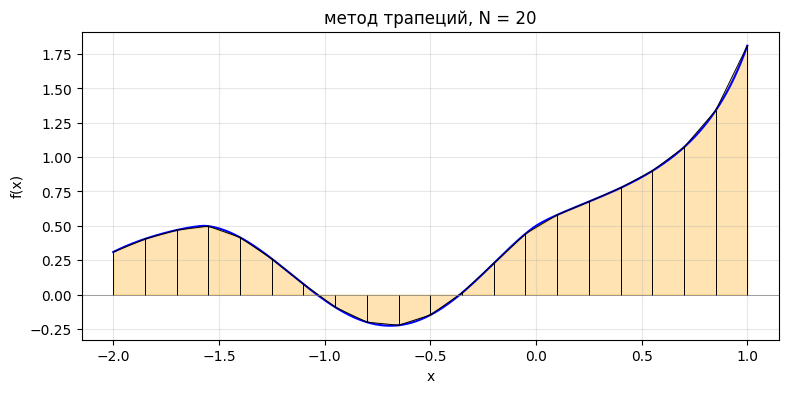

In [3]:
xs = np.linspace(a, b, 1000)
ys = f(xs)

N = 20
xk = np.linspace(a, b, N + 1)
yk = f(xk)

plt.figure(figsize=(9, 4))
plt.plot(xs, ys, 'b-')
plt.fill_between(xk, 0, yk, step=None, alpha=0.3, color='orange')
for i in range(N):
    plt.plot([xk[i], xk[i+1]], [yk[i], yk[i+1]], 'k-', lw=0.7)
    plt.plot([xk[i], xk[i]],   [0, yk[i]],     'k-', lw=0.7)
plt.plot([xk[-1], xk[-1]], [0, yk[-1]], 'k-', lw=0.7)
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'метод трапеций, N = {N}')
plt.grid(True, alpha=0.3)
plt.show()

## 2. полином из дз-1

из дз-1: степень $m = 2$, узлы по чебышёву на $[-2;1]$:

$x_0 = -\tfrac{1}{2} - \tfrac{3\sqrt{3}}{4} \approx -1{,}799038$,

$x_1 = -\tfrac{1}{2}$,

$x_2 = -\tfrac{1}{2} + \tfrac{3\sqrt{3}}{4} \approx \phantom{-}0{,}799038$.

значения функции и разделённые разности:

$f(x_0) \approx 0{,}429522$, $f(x_1) \approx -0{,}148641$, $f(x_2) \approx 1{,}232481$,

$f(x_0;x_1) \approx -0{,}445071$,

$f(x_1;x_2) \approx \phantom{-}1{,}063189$,

$f(x_0;x_1;x_2) \approx \phantom{-}0{,}580529$.

полином в форме ньютона:
$$
Q_2(x) = f(x_0) + (x - x_0)\,f(x_0;x_1) + (x - x_0)(x - x_1)\,f(x_0;x_1;x_2).
$$

In [4]:
m = 2
xi = np.array([-np.cos((2*i + 1) * np.pi / (2*m + 2)) for i in range(m + 1)])
x_nodes = (a + b)/2 + (b - a)/2 * xi
y_nodes = f(x_nodes)

f01  = (y_nodes[1] - y_nodes[0]) / (x_nodes[1] - x_nodes[0])
f12  = (y_nodes[2] - y_nodes[1]) / (x_nodes[2] - x_nodes[1])
f012 = (f12 - f01) / (x_nodes[2] - x_nodes[0])

A = y_nodes[0]
B = f01
C = f012
x0, x1, x2 = x_nodes
print(f"A = f(x0)         = {A:.6f}")
print(f"B = f(x0;x1)      = {B:.6f}")
print(f"C = f(x0;x1;x2)   = {C:.6f}")
print(f"x0 = {x0:.6f},  x1 = {x1:.6f},  x2 = {x2:.6f}")

A = f(x0)         = 0.429522
B = f(x0;x1)      = -0.445071
C = f(x0;x1;x2)   = 0.580529
x0 = -1.799038,  x1 = -0.500000,  x2 = 0.799038


## 3. ручное интегрирование $Q_2(x)$ на $[-2;1]$

$$
\int_a^b Q_2(x)\,dx
= A\!\!\int_a^b\!dx \;+\; B\!\!\int_a^b(x-x_0)\,dx \;+\; C\!\!\int_a^b(x-x_0)(x-x_1)\,dx.
$$

**первое слагаемое.**
$$
I_1 = A(b-a) = 0{,}429522\cdot 3 = 1{,}288567.
$$

**второе слагаемое.** первообразная $\dfrac{(x-x_0)^2}{2}$, значит
$$
\int_a^b(x-x_0)\,dx = \frac{(b-x_0)^2 - (a-x_0)^2}{2}.
$$
с $x_0 = -1{,}799038$:

$b - x_0 = 1 - (-1{,}799038) = 2{,}799038$, $(b - x_0)^2 = 7{,}834615$,

$a - x_0 = -2 - (-1{,}799038) = -0{,}200962$, $(a - x_0)^2 = 0{,}040386$,

$\int_a^b(x-x_0)\,dx = (7{,}834615 - 0{,}040386)/2 = 3{,}897114$,

$I_2 = B \cdot 3{,}897114 = -0{,}445071 \cdot 3{,}897114 = -1{,}734491$.

**третье слагаемое.** раскрываем произведение:
$$
(x-x_0)(x-x_1) = x^2 - (x_0+x_1)\,x + x_0 x_1,
$$
первообразная
$$
F(x) = \frac{x^3}{3} - \frac{x_0+x_1}{2}\,x^2 + x_0 x_1\, x.
$$
с $x_0 + x_1 = -2{,}299038$ и $x_0 x_1 = 0{,}899519$:

$F(1) = \tfrac{1}{3} - \tfrac{-2{,}299038}{2} + 0{,}899519 = 0{,}333333 + 1{,}149519 + 0{,}899519 = 2{,}382371$,

$F(-2) = \tfrac{-8}{3} - \tfrac{-2{,}299038}{2}\cdot 4 + 0{,}899519\cdot(-2) = -2{,}666667 + 4{,}598076 - 1{,}799038 = 0{,}132371$,

$\int_a^b(x-x_0)(x-x_1)\,dx = F(1) - F(-2) = 2{,}250000$,

$I_3 = C \cdot 2{,}250000 = 0{,}580529 \cdot 2{,}250000 = 1{,}306191$.

**сумма.**
$$
\int_{-2}^{1} Q_2(x)\,dx = I_1 + I_2 + I_3 = 1{,}288567 - 1{,}734491 + 1{,}306191 = 0{,}860267.
$$

In [5]:
I1 = A * (b - a)
I2 = B * ((b - x0)**2 - (a - x0)**2) / 2

def F(t):
    return t**3/3 - (x0 + x1)*t**2/2 + x0*x1*t

I3 = C * (F(b) - F(a))

I_Q2 = I1 + I2 + I3
print(f"I1 = {I1:.6f}")
print(f"I2 = {I2:.6f}")
print(f"I3 = {I3:.6f}")
print(f"интеграл Q2 на [-2;1] = {I_Q2:.6f}")

I1 = 1.288567


I2 = -1.734491
I3 = 1.306191
интеграл Q2 на [-2;1] = 0.860267


## 4. сравнение результатов

обозначим $I_f$ приближение интеграла исходной функции методом трапеций при достаточно большом $N$ и $I_{Q_2}$ интеграл полинома, найденный руками.

In [6]:
I_f = trapezoid(f, a, b, 10000)
print(f"I_f   (трапеция, N=10000) = {I_f:.6f}")
print(f"I_Q2  (руками)            = {I_Q2:.6f}")
print(f"разность |I_f - I_Q2|     = {abs(I_f - I_Q2):.6f}")

I_f   (трапеция, N=10000) = 1.274482
I_Q2  (руками)            = 0.860267
разность |I_f - I_Q2|     = 0.414215


расхождение значительное. это закономерно: полином степени 2 совпадает с $f$ только в трёх узлах, на остальной части отрезка остаётся систематическая ошибка $R_2(x) = f(x) - Q_2(x)$. интеграл от полинома равен интегралу от $f$ минус интеграл от $R_2$:
$$
\int_a^b Q_2(x)\,dx = \int_a^b f(x)\,dx - \int_a^b R_2(x)\,dx.
$$

на отрезке $[-2;1]$ функция меняется быстро (особенность тангенса вблизи $-\pi/2$, рост к правому концу), и полином второй степени не способен её повторить. поэтому интеграл от $Q_2$ заметно меньше интеграла от $f$. метод трапеций при больших $N$ даёт значение, существенно более близкое к истинному интегралу, чем интегрирование полинома малой степени.

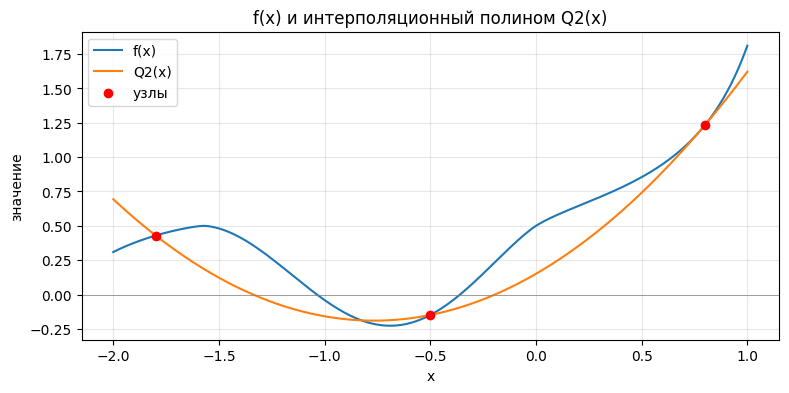

In [7]:
xs = np.linspace(a, b, 1000)
def Q2(x):
    return A + (x - x0)*B + (x - x0)*(x - x1)*C
plt.figure(figsize=(9, 4))
plt.plot(xs, f(xs), label='f(x)')
plt.plot(xs, Q2(xs), label='Q2(x)')
plt.scatter(x_nodes, y_nodes, color='red', zorder=5, label='узлы')
plt.axhline(0, color='gray', lw=0.5)
plt.xlabel('x')
plt.ylabel('значение')
plt.title('f(x) и интерполяционный полином Q2(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()